In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'


In [2]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 5
plt.rcParams['figure.figsize'] = (3.5, 2.5)
plt.rcParams['figure.dpi'] = 150

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2

# Figure 1e

In [12]:
# user-defined parameters
bins = np.linspace(0, 1000, 101)
loop_num = 0
noise = 50  # nm (can be 0,10,...,50)

# open the data
df_hist_3D_looping = pd.read_pickle("../data/3D_dist_histograms_with_looping.pkl")


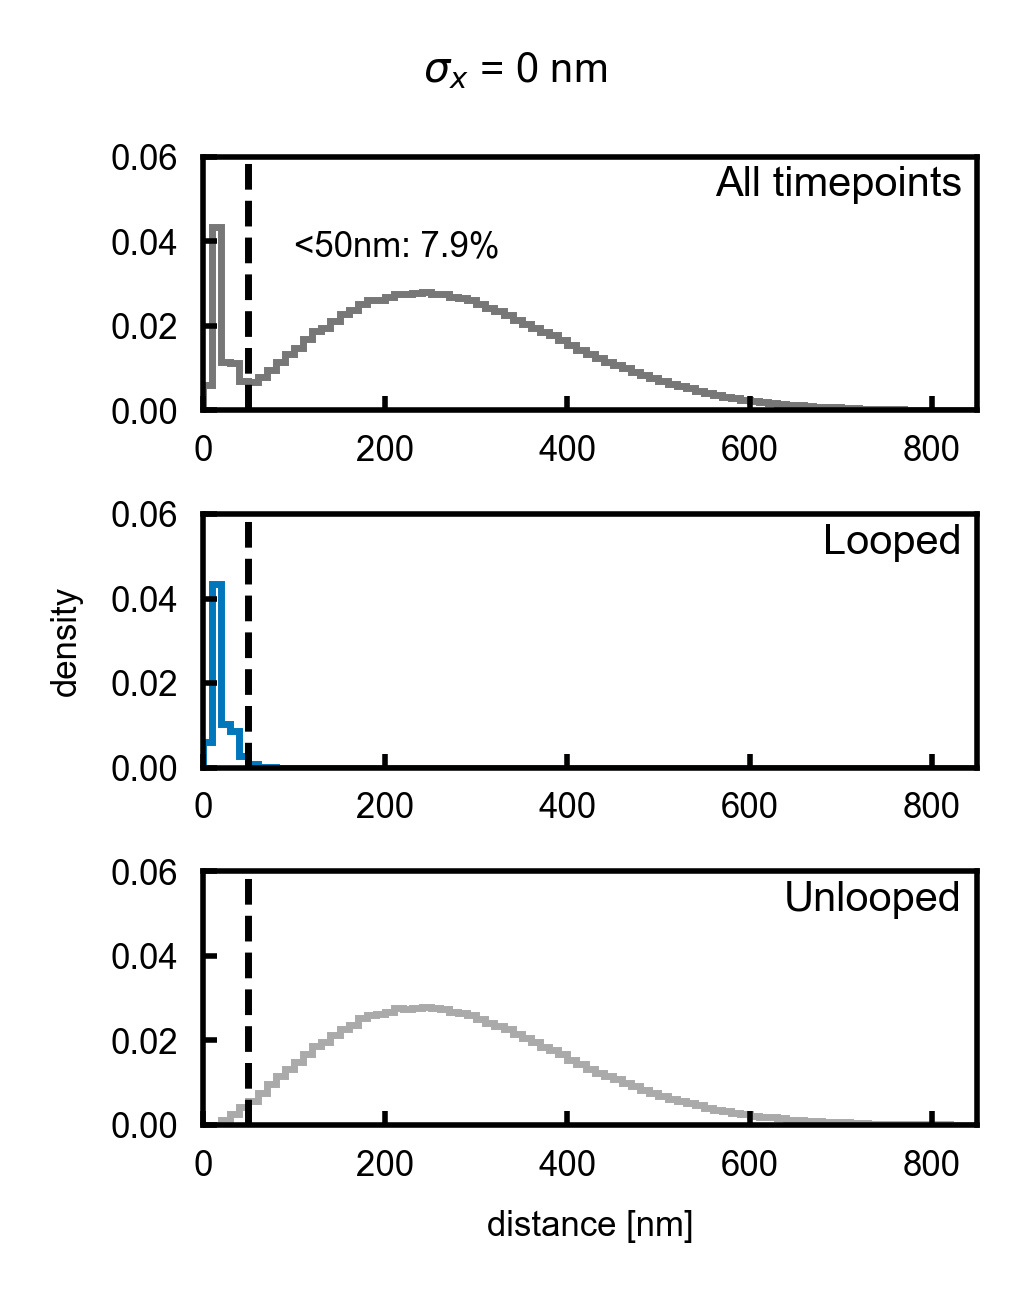

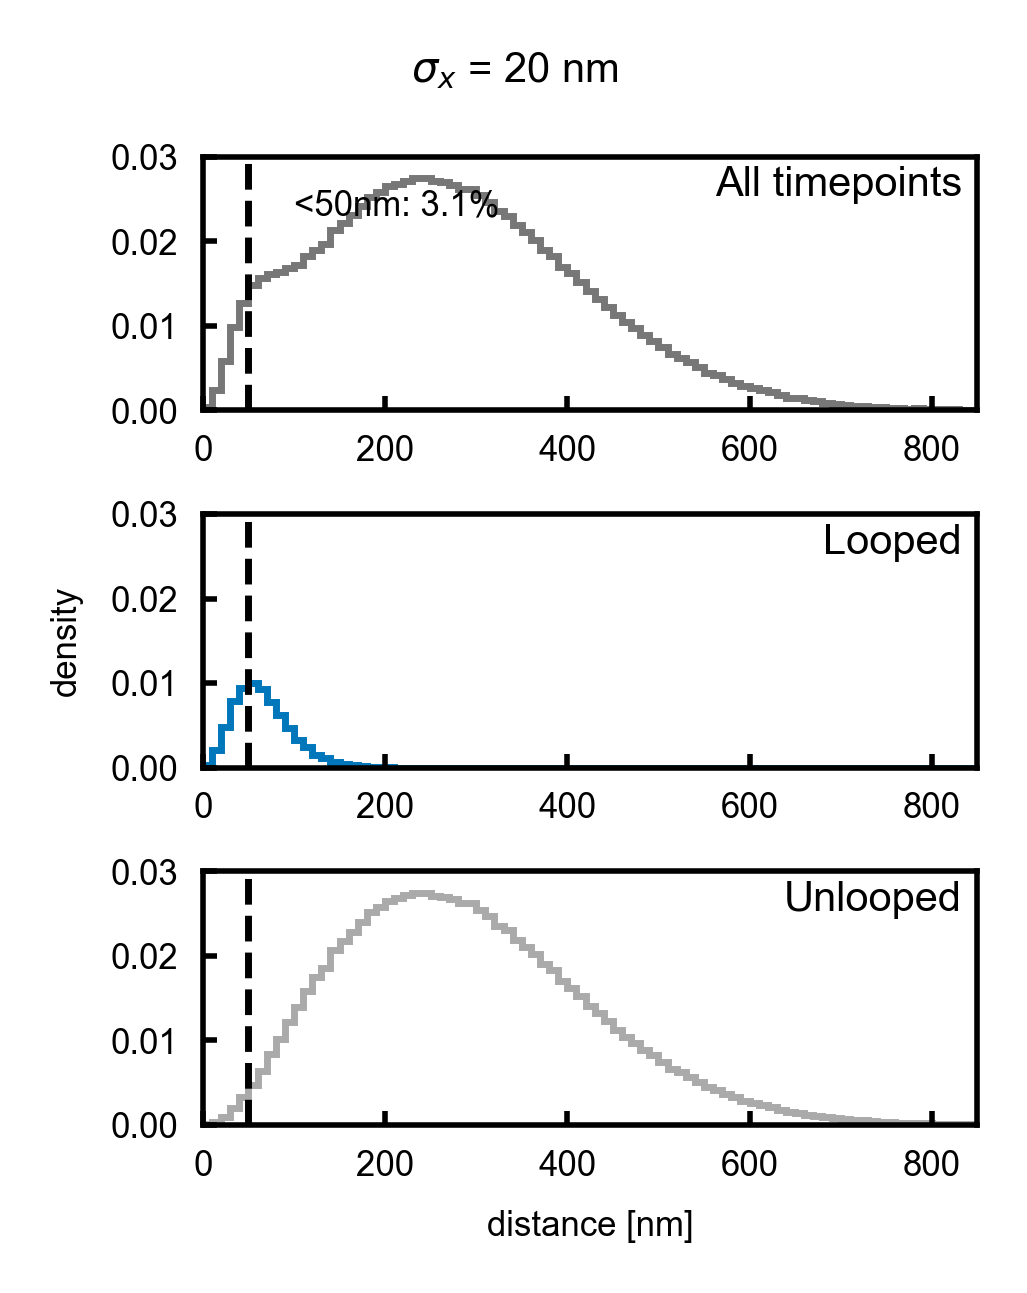

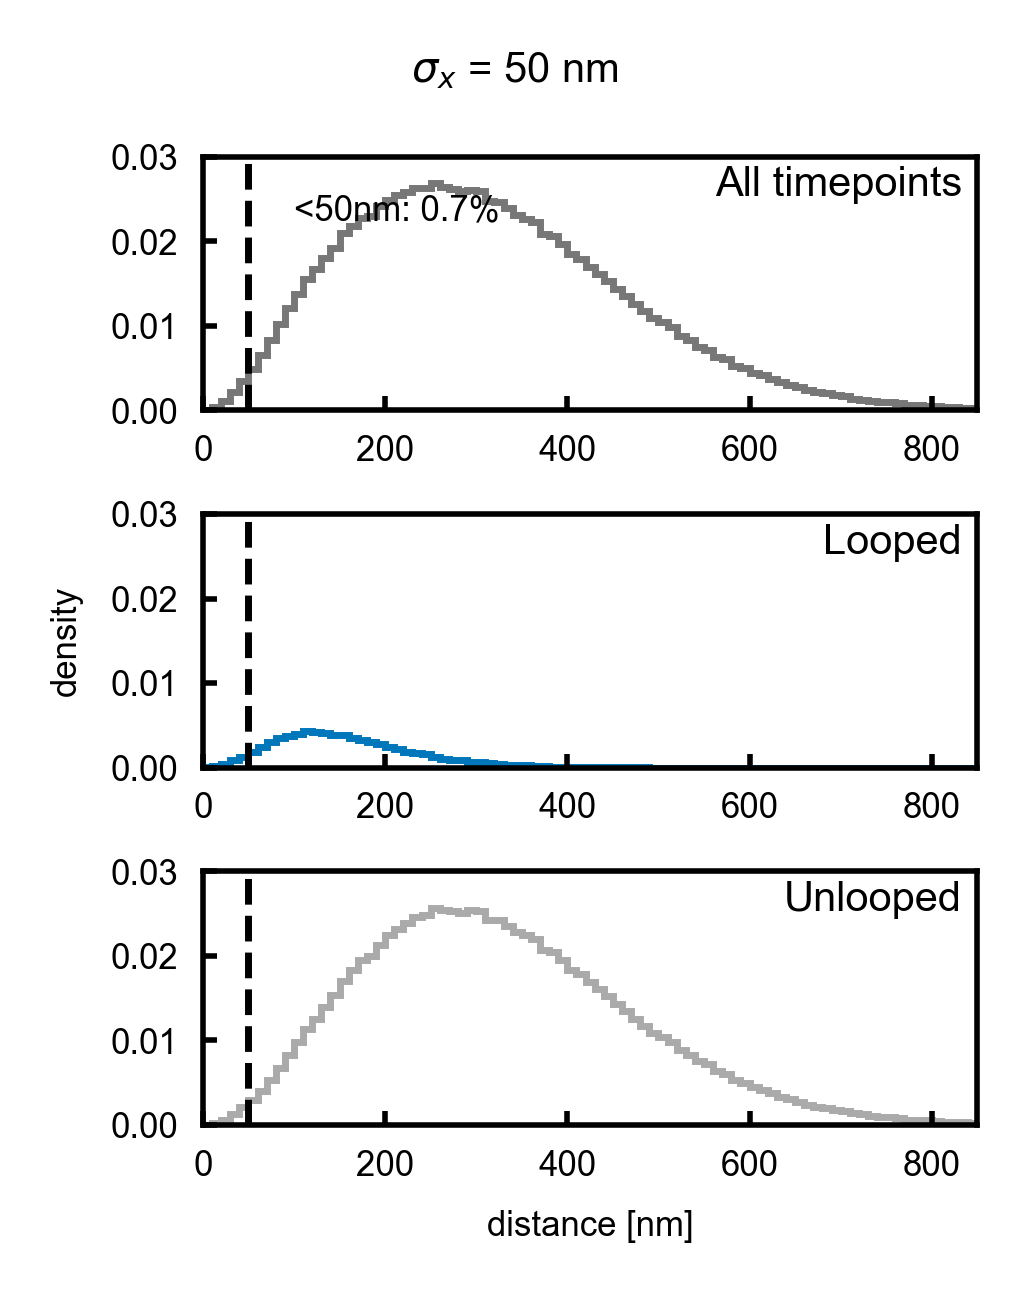

In [13]:
ymax_values = [0.06, 0.03, 0.03]

for k, noise in enumerate([0, 20, 50]):

    fig, axs = plt.subplots(3, 1, figsize=(2, 2.5), dpi=250)

    # select the relevant data
    hist_looped = df_hist_3D_looping.loc[(df_hist_3D_looping["loop"]==loop_num) & (df_hist_3D_looping["noise"]==noise), "hist_looped"].iloc[0]
    hist_unlooped = df_hist_3D_looping.loc[(df_hist_3D_looping["loop"]==loop_num) & (df_hist_3D_looping["noise"]==noise), "hist_unlooped"].iloc[0]

    # reconstruct full distributions
    dist_3D_looped = np.repeat(np.arange(len(hist_looped)), hist_looped)
    dist_3D_unlooped = np.repeat(np.arange(len(hist_unlooped)), hist_unlooped)
    
    bins = np.linspace(0, 1000, 101)

    num_timepoints_total = len(dist_3D_looped) + len(dist_3D_unlooped)

    hist_all, bin_edges = np.histogram(np.concatenate((dist_3D_looped, dist_3D_unlooped)), bins=bins)
    hist_all = hist_all / num_timepoints_total
    hist_looped, bin_edges = np.histogram(dist_3D_looped, bins=bins)
    hist_looped = hist_looped / num_timepoints_total
    hist_unlooped, bin_edges = np.histogram(dist_3D_unlooped, bins=bins)
    hist_unlooped = hist_unlooped / num_timepoints_total

    axs[0].stairs(hist_all, bin_edges, color='#777777')
    axs[0].set_title('All timepoints', y=0.8, va='top', x=0.98, ha='right')
    
    frac_below_50 = np.mean(np.concatenate((dist_3D_looped, dist_3D_unlooped))<50)
    axs[0].text(100, axs[0].get_ylim()[1]*0.8, f"<50nm: {frac_below_50:.1%}")
    
    axs[1].stairs(hist_looped, bin_edges, color='#0077bb')
    axs[1].set_title('Looped', y=0.8, va='top', x=0.98, ha='right')
    axs[2].stairs(hist_unlooped, bin_edges, color='#aaaaaa')
    axs[2].set_title('Unlooped', y=0.8, va='top', x=0.98, ha='right')

    for i in range(3):
        axs[i].set_ylim(0, ymax_values[k])
        axs[i].set_xlim(0, 850)
        axs[i].axvline(50, 0, 1, linewidth=1, linestyle='--', color='black')  # show threshold at 50nm
    axs[2].set_xlabel('distance [nm]')
    axs[1].set_ylabel('density')

    plt.suptitle(rf'$\sigma_x$ = {noise} nm')

    plt.tight_layout()

    plt.savefig(f'../figure_exports/fig1e_{noise}nm.svg')


# Figure 1f

In [14]:
looping_probs = pd.read_csv('../data/looping_probs.csv')
probs_under_threshold = pd.read_csv('../data/probs_under_threshold.csv', comment='#')

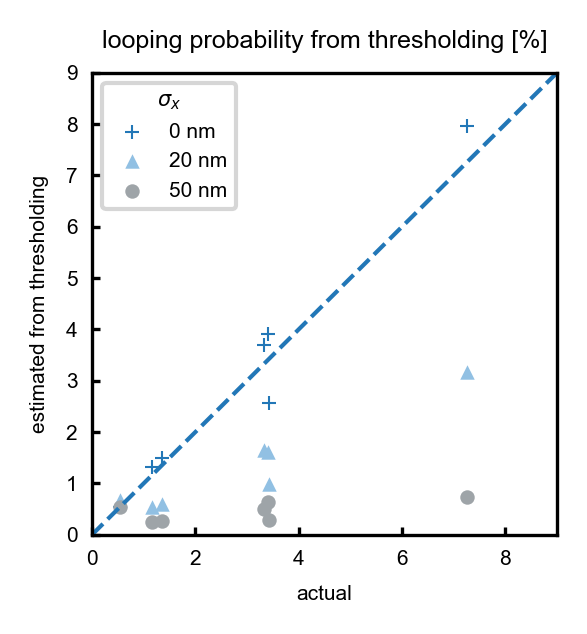

In [20]:
fig, ax = plt.subplots(figsize=(2,2), dpi=150)

colors = ['#2277b7','#91c0e3','#9ea4a8']
markers = ['+','^','o']

for i, noise in enumerate([0, 20, 50]):
    x = looping_probs.loc[:6, 'looping_prob'] * 100
    y = probs_under_threshold.loc[:6, str(noise)] * 100
    ax.scatter(x, y, s=(10 if i==0 else 12), marker=markers[i], color=colors[i], linewidth=(0.5 if i==0 else 0))
ax.plot([0, 10], [0, 10], linestyle='--', linewidth=1, color=colors[0])
ax.set_xlim(0, 9)
ax.set_ylim(0, 9)

ax.set_xlabel('actual')
ax.set_ylabel('estimated from thresholding');
ax.legend(['0 nm', '20 nm', '50 nm'], title=r'$\sigma_{x}$');
ax.set_title('looping probability from thresholding [%]');

plt.savefig(f'../figure_exports/fig1f.svg')
